# 09 - Paper figures and qualitative segmentation examples

Segmentation and retrieval figures used in the paper, including four fixed qualitative cases.

In [1]:
from pathlib import Path
import os
import sys

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root not found. Run from the project tree or set BRATS_PROJECT_ROOT."
    )

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

os.chdir(PROJECT_ROOT)

print("Project:", PROJECT_ROOT)

Project: /home/mandrakedrink/projects/research_ts_bs


## Imports

In [2]:
import copy
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from IPython.display import display

import torch

from brats_pipeline.common import (
    ProjectPaths,
    array_digest,
    file_digest,
    load_array_cache,
    save_array_cache,
)
from brats_pipeline.data import (
    jp,
    load_nii as _load_nii,
    normalize_nonzero,
    remap_brats_labels,
    xyz_to_dhw,
)
from brats_pipeline.inference import (
    create_segresnet,
    load_trusted_checkpoint,
    extract_model_state_dict,
    predict_labels_dhw,
    brats_region_dice_np,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
load_nii = partial(_load_nii, project_root=PROJECT_ROOT)

## Configuration

In [3]:
CFG = {
    "manifest": "data/processed/manifest_4clients_seed42.csv",
    "analysis_split": "test",
    "output_dir": "docs/09_qualitative_segmentation_examples_test",

    # Full-volume inference settings.
    "roi_size": (128, 128, 128),
    "sw_batch_size": 1,
    "overlap": 0.5,

    # Display.
    "modality_name": "FLAIR",
    "modality_index": 3,
    "figure_dpi": 300,
    "anonymize_case_names": True,
    "show_case_domain": True,
    "show_metric_labels": True,

    # Qualitative panel layout.
    "figure_total_width": 12.2,
    "figure_row_height_4rows": 2.05,
    "figure_extra_height": 0.78,
    "subplot_wspace": 0.04,
    "subplot_hspace": -0.16,

    # Typography.
    "font_suptitle": 22,
    "font_column_title": 16,
    "font_metric_label_4rows": 10.2,
    "font_case_label": 13,
    "legend_marker_size": 42,
    "legend_font_size": 24,

    # Plot colors used in the paper.
    "paper_model_colors": {
        "centralized_s32": "#3B78A0",
        "fedavg_s32": "#45B39D",
        "fedprox_s32": "#E1A325",
    },
    "paper_random_baseline_color": "#E76F51",
    "paper_enrichment_color": "#8E5AD7",
    "paper_grid_color": "#D6DCE5",
    "paper_spine_color": "#666666",
    "paper_bar_edgecolor": "#2F2F2F",

    # Prediction cache.
    "force_recompute_predictions": False,
}

PAPER_CASES = [
    {"case_label": "Case A", "patient_id": "BraTS2021_00283", "client_domain": "UPENN-GBM", "slice_z": 94},
    {"case_label": "Case B", "patient_id": "BraTS2021_00663", "client_domain": "UCSF-PDGM", "slice_z": 72},
    {"case_label": "Case C", "patient_id": "BraTS2021_00144", "client_domain": "TCGA-GBM", "slice_z": 54},
    {"case_label": "Case D", "patient_id": "BraTS2021_01493", "client_domain": "TCGA-LGG", "slice_z": 59},
]

COMMON_MODEL_KWARGS = {
    "spatial_dims": 3,
    "in_channels": 4,
    "out_channels": 4,
    "init_filters": 32,
    "blocks_down": (1, 2, 2, 4),
    "blocks_up": (1, 1, 1),
    "dropout_prob": 0.1,
}

EXPERIMENTS = {
    "centralized_s32": {
        "display_name": "Centralized S32",
        "checkpoint": "models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt",
        "metrics_path": "models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
        "model_kwargs": COMMON_MODEL_KWARGS,
    },
    "fedavg_s32": {
        "display_name": "FedAvg S32",
        "checkpoint": "models/federated_fedavg_segresnet32_final/fedavg_best_mean_dice.pt",
        "metrics_path": "models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
        "model_kwargs": COMMON_MODEL_KWARGS,
    },
    "fedprox_s32": {
        "display_name": "FedProx S32",
        "checkpoint": "models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt",
        "metrics_path": "models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
        "model_kwargs": COMMON_MODEL_KWARGS,
    },
}

MODEL_ORDER = ["centralized_s32", "fedavg_s32", "fedprox_s32"]
PAPER_CASE_IDS = [item["patient_id"] for item in PAPER_CASES]
PAPER_CASE_BY_ID = {item["patient_id"]: item for item in PAPER_CASES}

## Output directories

In [4]:
OUTPUT_DIR = paths_io.output(CFG["output_dir"])
FIG_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "prediction_cache"
TABLE_DIR = OUTPUT_DIR / "tables"

for directory in [OUTPUT_DIR, FIG_DIR, CACHE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test


## Manifest and full-volume metrics

In [5]:
manifest_path = resolve_existing_path(CFG["manifest"], label="manifest")
manifest_df = pd.read_csv(manifest_path)

required_manifest_cols = {"patient_id", "client_domain", "split", "paths"}
missing = required_manifest_cols - set(manifest_df.columns)
if missing:
    raise ValueError(f"Manifest missing columns: {sorted(missing)}")

test_df = manifest_df[
    manifest_df["split"].astype(str) == CFG["analysis_split"]
].reset_index(drop=True)

metrics_by_model = {}

for model_key, exp in EXPERIMENTS.items():
    metrics_path = resolve_existing_path(
        exp["metrics_path"],
        label=f"{model_key} full-volume metrics",
    )
    metrics_df = pd.read_csv(metrics_path)

    required_metric_cols = {
        "patient_id",
        "client_domain",
        "split",
        "dice_WT",
        "dice_TC",
        "dice_ET",
    }
    missing = required_metric_cols - set(metrics_df.columns)
    if missing:
        raise ValueError(
            f"{model_key} metrics missing columns: {sorted(missing)}"
        )

    metrics_df = metrics_df[
        metrics_df["split"].astype(str) == CFG["analysis_split"]
    ].reset_index(drop=True)

    metrics_by_model[model_key] = metrics_df

print("Held-out test cases:", len(test_df))
display(test_df.groupby("client_domain").size().rename("n_test").to_frame())

Held-out test cases: 211


,n_test
client_domain,
TCGA-GBM,20
TCGA-LGG,13
UCSF-PDGM,76
UPENN-GBM,102


## Validate the four paper cases

In [6]:
validation_rows = []

for spec in PAPER_CASES:
    pid = spec["patient_id"]
    rows = test_df[test_df["patient_id"].astype(str) == pid]

    if len(rows) != 1:
        raise ValueError(
            f"Expected exactly one TEST manifest row for {pid}, found {len(rows)}."
        )

    row = rows.iloc[0]
    actual_domain = str(row["client_domain"])

    if actual_domain != spec["client_domain"]:
        raise ValueError(
            f"{pid}: expected domain {spec['client_domain']}, found {actual_domain}."
        )

    for model_key, metrics_df in metrics_by_model.items():
        n_rows = int((metrics_df["patient_id"].astype(str) == pid).sum())
        if n_rows != 1:
            raise ValueError(
                f"{model_key}: expected one metric row for {pid}, found {n_rows}."
            )

    validation_rows.append({
        "case": spec["case_label"],
        "patient_id": pid,
        "client_domain": actual_domain,
        "split": row["split"],
        "slice_z": spec["slice_z"],
    })

paper_case_table = pd.DataFrame(validation_rows)
display(paper_case_table)

,case,patient_id,client_domain,split,slice_z
0,Case A,BraTS2021_00283,UPENN-GBM,test,94
1,Case B,BraTS2021_00663,UCSF-PDGM,test,72
2,Case C,BraTS2021_00144,TCGA-GBM,test,54
3,Case D,BraTS2021_01493,TCGA-LGG,test,59


## Case loading

In [7]:
def load_full_case_by_pid(patient_id):
    rows = test_df[test_df["patient_id"].astype(str) == str(patient_id)]

    if len(rows) != 1:
        raise ValueError(
            f"Expected exactly one TEST row for patient_id={patient_id}, got {len(rows)}."
        )

    row = rows.iloc[0]
    paths = jp(row["paths"])

    images = []
    for modality in ["t1", "t1ce", "t2", "flair"]:
        volume = load_nii(paths[modality], dtype=np.float32)
        volume = normalize_nonzero(volume)
        images.append(volume)

    image_xyz = np.stack(images, axis=0).astype(np.float32)

    seg_xyz = load_nii(paths["seg"], dtype=np.uint8)
    seg_xyz = remap_brats_labels(seg_xyz)

    image_dhw, seg_dhw = xyz_to_dhw(image_xyz, seg_xyz)

    return {
        "patient_id": str(patient_id),
        "client_domain": str(row["client_domain"]),
        "split": str(row["split"]),
        "image_dhw": image_dhw,
        "seg_dhw": seg_dhw,
        "paths": paths,
    }

## Models and prediction cache

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

_MODEL_CACHE = {}
_CHECKPOINT_HASHES = {}


def load_model_for_experiment(model_key):
    exp = EXPERIMENTS[model_key]
    checkpoint = resolve_existing_path(
        exp["checkpoint"],
        label=f"{model_key} checkpoint",
    )

    checkpoint_obj = load_trusted_checkpoint(checkpoint, map_location=device)

    model = create_segresnet(copy.deepcopy(exp["model_kwargs"])).to(device)
    model.load_state_dict(
        extract_model_state_dict(checkpoint_obj),
        strict=True,
    )
    model.eval()

    print("loaded:", model_key, "->", checkpoint)
    return model


def get_loaded_model(model_key):
    if model_key not in _MODEL_CACHE:
        _MODEL_CACHE[model_key] = load_model_for_experiment(model_key)
    return _MODEL_CACHE[model_key]


def predict_full_volume(model, image_dhw):
    return predict_labels_dhw(
        model,
        image_dhw,
        device,
        roi_size=CFG["roi_size"],
        sw_batch_size=CFG["sw_batch_size"],
        overlap=CFG["overlap"],
        mode="gaussian",
    )


def get_prediction(model_key, case):
    checkpoint = resolve_existing_path(
        EXPERIMENTS[model_key]["checkpoint"],
        label=f"{model_key} checkpoint",
    )

    checkpoint_key = (
        str(checkpoint),
        checkpoint.stat().st_size,
        checkpoint.stat().st_mtime_ns,
    )

    if checkpoint_key not in _CHECKPOINT_HASHES:
        _CHECKPOINT_HASHES[checkpoint_key] = file_digest(checkpoint)

    cache_payload = {
        "patient_id": case["patient_id"],
        "input_dhw": array_digest(case["image_dhw"]),
        "checkpoint_sha256": _CHECKPOINT_HASHES[checkpoint_key],
        "model_kwargs": EXPERIMENTS[model_key]["model_kwargs"],
        "roi_size": CFG["roi_size"],
        "sw_batch_size": CFG["sw_batch_size"],
        "overlap": CFG["overlap"],
        "mode": "gaussian",
        "decision": "argmax",
    }

    cache_dir = CACHE_DIR / model_key / case["patient_id"]

    cached = None
    if not CFG["force_recompute_predictions"]:
        cached = load_array_cache(
            cache_dir,
            cache_payload,
            ["pred_dhw"],
        )

    if cached is None:
        model = get_loaded_model(model_key)
        pred_dhw = predict_full_volume(model, case["image_dhw"])
        save_array_cache(
            cache_dir,
            cache_payload,
            {"pred_dhw": pred_dhw},
        )
    else:
        pred_dhw = cached["pred_dhw"]

    if pred_dhw.shape != case["seg_dhw"].shape:
        raise ValueError(
            f"{model_key}, {case['patient_id']}: prediction shape "
            f"{pred_dhw.shape} != GT shape {case['seg_dhw'].shape}."
        )

    # Verify the displayed prediction against the stored full-volume metrics.
    actual = brats_region_dice_np(pred_dhw, case["seg_dhw"])

    metric_row = metrics_by_model[model_key][
        metrics_by_model[model_key]["patient_id"].astype(str) == case["patient_id"]
    ]

    if len(metric_row) != 1:
        raise ValueError(
            f"{model_key}: expected one metric row for {case['patient_id']}."
        )

    metric_row = metric_row.iloc[0]

    expected = {
        "dice_WT": float(metric_row["dice_WT"]),
        "dice_TC": float(metric_row["dice_TC"]),
        "dice_ET": float(metric_row["dice_ET"]),
    }

    if not np.allclose(
        [actual["dice_WT"], actual["dice_TC"], actual["dice_ET"]],
        [expected["dice_WT"], expected["dice_TC"], expected["dice_ET"]],
        atol=1e-4,
        rtol=0.0,
    ):
        raise ValueError(
            f"{model_key}, {case['patient_id']}: displayed prediction does not "
            "reproduce the stored full-volume Dice metrics."
        )

    return pred_dhw


def clear_model_cache():
    for model in _MODEL_CACHE.values():
        try:
            model.cpu()
        except Exception:
            pass

    _MODEL_CACHE.clear()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Model cache cleared.")

device: cuda
gpu: NVIDIA GeForce RTX 4090


## Load the four fixed cases and predictions

In [9]:
cases = {}
predictions = {}

for patient_id in PAPER_CASE_IDS:
    case = load_full_case_by_pid(patient_id)
    cases[patient_id] = case
    predictions[patient_id] = {}

    print(
        "\ncase:",
        patient_id,
        "|",
        case["client_domain"],
        "|",
        case["image_dhw"].shape,
    )

    for model_key in MODEL_ORDER:
        pred_dhw = get_prediction(model_key, case)
        predictions[patient_id][model_key] = pred_dhw
        print(" ", model_key, pred_dhw.shape, "labels", np.unique(pred_dhw))


case: BraTS2021_00283 | UPENN-GBM | (4, 155, 240, 240)
  centralized_s32 (155, 240, 240) labels [0 1 2 3]
  fedavg_s32 (155, 240, 240) labels [0 1 2 3]
  fedprox_s32 (155, 240, 240) labels [0 1 2 3]

case: BraTS2021_00663 | UCSF-PDGM | (4, 155, 240, 240)
  centralized_s32 (155, 240, 240) labels [0 1 2 3]
  fedavg_s32 (155, 240, 240) labels [0 1 2 3]
  fedprox_s32 (155, 240, 240) labels [0 1 2 3]

case: BraTS2021_00144 | TCGA-GBM | (4, 155, 240, 240)
  centralized_s32 (155, 240, 240) labels [0 1 2 3]
  fedavg_s32 (155, 240, 240) labels [0 1 2 3]
  fedprox_s32 (155, 240, 240) labels [0 1 2 3]

case: BraTS2021_01493 | TCGA-LGG | (4, 155, 240, 240)
  centralized_s32 (155, 240, 240) labels [0 1 2 3]
  fedavg_s32 (155, 240, 240) labels [0 1 2 3]
  fedprox_s32 (155, 240, 240) labels [0 1 2 3]


## Paper figure helpers

In [10]:
REGION_COLORS = {
    "WT": "#00B050",
    "TC": "#B000FF",
    "ET": "#FF8F00",
}

REGION_ALPHA = {
    "WT": 0.14,
    "TC": 0.00,
    "ET": 0.10,
}

REGION_NAMES = {
    "WT": "WT",
    "TC": "TC",
    "ET": "ET",
}


def robust_slice_display(x, p_low=1, p_high=99):
    x = np.asarray(x, dtype=np.float32)
    finite = np.isfinite(x)

    if finite.sum() == 0:
        return np.zeros_like(x, dtype=np.float32)

    values = x[finite]
    lo, hi = np.percentile(values, [p_low, p_high])
    clipped = np.clip(x, lo, hi)

    return (clipped - lo) / (hi - lo + 1e-8)


def mask_to_regions(mask_slice):
    return {
        "WT": mask_slice > 0,
        "TC": np.isin(mask_slice, [1, 3]),
        "ET": mask_slice == 3,
    }


def add_mask_overlay(ax, mask_slice, contour=True):
    regions = mask_to_regions(mask_slice)

    # Light fills. TC is contour-only so nested regions stay readable.
    for region in ["WT", "TC", "ET"]:
        region_mask = regions[region]

        if not np.any(region_mask):
            continue

        alpha = REGION_ALPHA[region]
        if alpha <= 0:
            continue

        rgb = mcolors.to_rgb(REGION_COLORS[region])
        rgba = np.zeros((*mask_slice.shape, 4), dtype=np.float32)
        rgba[region_mask, :3] = rgb
        rgba[region_mask, 3] = alpha

        ax.imshow(rgba, interpolation="nearest")

    if not contour:
        return

    # WT: solid green outer contour.
    if np.any(regions["WT"]):
        ax.contour(
            regions["WT"],
            levels=[0.5],
            colors=[REGION_COLORS["WT"]],
            linewidths=1.45,
            linestyles="solid",
            zorder=3,
        )

    # ET: white underlay + orange solid contour.
    if np.any(regions["ET"]):
        ax.contour(
            regions["ET"],
            levels=[0.5],
            colors=["white"],
            linewidths=2.0,
            linestyles="solid",
            zorder=5,
        )
        ax.contour(
            regions["ET"],
            levels=[0.5],
            colors=[REGION_COLORS["ET"]],
            linewidths=1.35,
            linestyles="solid",
            zorder=6,
        )

    # TC is drawn last as a dashed purple contour so it remains visible over ET.
    if np.any(regions["TC"]):
        ax.contour(
            regions["TC"],
            levels=[0.5],
            colors=["white"],
            linewidths=2.8,
            linestyles="--",
            zorder=7,
        )
        ax.contour(
            regions["TC"],
            levels=[0.5],
            colors=[REGION_COLORS["TC"]],
            linewidths=2.0,
            linestyles="--",
            zorder=8,
        )


def get_metrics_for_case(patient_id, model_key):
    rows = metrics_by_model[model_key][
        metrics_by_model[model_key]["patient_id"].astype(str) == str(patient_id)
    ]

    if len(rows) != 1:
        return None

    row = rows.iloc[0]

    return (
        float(row["dice_WT"]),
        float(row["dice_TC"]),
        float(row["dice_ET"]),
    )


def dice_label(model_key, patient_id):
    values = get_metrics_for_case(patient_id, model_key)

    if values is None or not CFG["show_metric_labels"]:
        return ""

    wt, tc, et = values
    return f"WT {wt:.2f}|TC {tc:.2f}|ET {et:.2f}"


def case_row_label(case_idx, spec):
    label = spec["case_label"]

    if CFG["show_case_domain"]:
        label += f"\n{spec['client_domain']}"

    if not CFG["anonymize_case_names"]:
        label += f"\n{spec['patient_id']}"

    label += f"\nSlice {spec['slice_z']}"
    return label


PAPER_MODEL_COLORS = CFG["paper_model_colors"]
PAPER_RANDOM_BASELINE_COLOR = CFG["paper_random_baseline_color"]
PAPER_ENRICHMENT_COLOR = CFG["paper_enrichment_color"]


def style_paper_axes(ax, y_grid=True):
    ax.set_facecolor("white")
    if y_grid:
        ax.grid(axis="y", color=CFG["paper_grid_color"], linewidth=0.8, alpha=0.9)
        ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(CFG["paper_spine_color"])
    ax.spines["bottom"].set_color(CFG["paper_spine_color"])
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)


def add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=9, rotation=0, y_pad_frac=0.012):
    ylim = ax.get_ylim()
    y_span = ylim[1] - ylim[0]
    for bar in bars:
        h = float(bar.get_height())
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            h + y_span * y_pad_frac,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=rotation,
            fontweight="bold",
        )



def heatmap_text_color(value, cmap, vmin=0.0, vmax=1.0):
    norm_value = (float(value) - vmin) / (vmax - vmin + 1e-8)
    rgba = cmap(np.clip(norm_value, 0.0, 1.0))
    r, g, b = rgba[:3]
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "black" if luminance >= 0.6 else "white"


def save_current_figure(fig, out_base):
    out_base = Path(out_base)
    out_base.parent.mkdir(parents=True, exist_ok=True)
    for ext in ["png", "pdf", "svg"]:
        fig.savefig(out_base.with_suffix(f".{ext}"), dpi=CFG["figure_dpi"], bbox_inches="tight", facecolor="white")
    print("saved:", out_base)

## Build metadata for the fixed paper panel

In [11]:
def build_paper_metadata():
    rows = []

    for spec in PAPER_CASES:
        patient_id = spec["patient_id"]

        row = {
            "case_label": spec["case_label"],
            "patient_id": patient_id,
            "client_domain": spec["client_domain"],
            "split": CFG["analysis_split"],
            "display_slice_z_dhw": spec["slice_z"],
            "anonymized_in_figure": CFG["anonymize_case_names"],
        }

        for model_key in MODEL_ORDER:
            wt, tc, et = get_metrics_for_case(patient_id, model_key)
            row[f"{model_key}_dice_WT"] = wt
            row[f"{model_key}_dice_TC"] = tc
            row[f"{model_key}_dice_ET"] = et

        rows.append(row)

    return pd.DataFrame(rows)


paper_metadata_df = build_paper_metadata()
display(paper_metadata_df)

,case_label,patient_id,client_domain,split,display_slice_z_dhw,anonymized_in_figure,centralized_s32_dice_WT,centralized_s32_dice_TC,centralized_s32_dice_ET,fedavg_s32_dice_WT,fedavg_s32_dice_TC,fedavg_s32_dice_ET,fedprox_s32_dice_WT,fedprox_s32_dice_TC,fedprox_s32_dice_ET
0,Case A,BraTS2021_00283,UPENN-GBM,test,94,True,0.930540,0.967905,0.934223,0.899750,0.963468,0.928354,0.905845,0.960076,0.926582
1,Case B,BraTS2021_00663,UCSF-PDGM,test,72,True,0.953242,0.987078,0.973427,0.954978,0.989355,0.976046,0.959824,0.988638,0.976084
2,Case C,BraTS2021_00144,TCGA-GBM,test,54,True,0.912915,0.953514,0.870998,0.925326,0.957545,0.880581,0.917301,0.954842,0.873860
3,Case D,BraTS2021_01493,TCGA-LGG,test,59,True,0.920620,0.784680,0.891287,0.911088,0.753032,0.885442,0.919138,0.752765,0.886851


## Four-domain qualitative figure

In [12]:
def create_paper_qualitative_figure():
    n_cases = len(PAPER_CASES)
    n_cols = 2 + len(MODEL_ORDER)

    fig_height = (
        CFG["figure_row_height_4rows"] * n_cases
        + CFG["figure_extra_height"]
    )

    fig, axes = plt.subplots(
        n_cases,
        n_cols,
        figsize=(CFG["figure_total_width"], fig_height),
        squeeze=False,
    )

    column_titles = [
        CFG["modality_name"],
        "Ground truth",
        *[EXPERIMENTS[key]["display_name"] for key in MODEL_ORDER],
    ]

    for row_idx, spec in enumerate(PAPER_CASES):
        patient_id = spec["patient_id"]
        z = int(spec["slice_z"])

        case = cases[patient_id]
        pred_dict = predictions[patient_id]

        if not (0 <= z < case["seg_dhw"].shape[0]):
            raise IndexError(
                f"{patient_id}: slice {z} is outside depth "
                f"{case['seg_dhw'].shape[0]}."
            )

        base = case["image_dhw"][CFG["modality_index"], z]
        base = robust_slice_display(base)

        gt_slice = case["seg_dhw"][z]

        panels = [
            None,
            gt_slice,
            *[pred_dict[key][z] for key in MODEL_ORDER],
        ]

        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]

            ax.imshow(
                base,
                cmap="gray",
                interpolation="nearest",
            )
            ax.axis("off")
            ax.set_aspect("equal")
            ax.set_anchor("C")

            if col_idx > 0:
                add_mask_overlay(ax, panels[col_idx])

            if row_idx == 0:
                ax.set_title(
                    column_titles[col_idx],
                    fontsize=CFG["font_column_title"],
                    fontweight="bold",
                    pad=6,
                )

            if col_idx >= 2 and CFG["show_metric_labels"]:
                model_key = MODEL_ORDER[col_idx - 2]
                label_text = dice_label(model_key, patient_id)

                ax.add_patch(
                    Rectangle(
                        (0.0, 0.900),
                        1.0,
                        0.100,
                        transform=ax.transAxes,
                        facecolor="black",
                        edgecolor="none",
                        alpha=0.72,
                        zorder=20,
                        clip_on=True,
                    )
                )

                ax.text(
                    0.50,
                    0.950,
                    label_text,
                    transform=ax.transAxes,
                    va="center",
                    ha="center",
                    fontsize=CFG["font_metric_label_4rows"],
                    fontweight="bold",
                    color="white",
                    zorder=21,
                    clip_on=True,
                )

            if col_idx == 0:
                ax.text(
                    -0.090,
                    0.5,
                    case_row_label(row_idx, spec),
                    transform=ax.transAxes,
                    va="center",
                    ha="right",
                    fontsize=CFG["font_case_label"],
                    fontweight="bold",
                    rotation=90,
                    clip_on=False,
                )

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="s",
            linestyle="None",
            markersize=CFG["legend_marker_size"],
            markerfacecolor=REGION_COLORS[region],
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=REGION_NAMES[region],
        )
        for region in ["WT", "TC", "ET"]
    ]

    fig.suptitle(
        "Held-out test segmentation examples",
        fontsize=CFG["font_suptitle"],
        fontweight="bold",
        y=0.985,
    )

    fig.subplots_adjust(
        left=0.060,
        right=0.995,
        top=0.895,
        bottom=0.115,
        wspace=CFG["subplot_wspace"],
        hspace=CFG["subplot_hspace"],
    )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        fontsize=CFG["legend_font_size"],
        columnspacing=2.2,
        handletextpad=0.55,
        bbox_to_anchor=(0.5, 0.022),
    )

    return fig


def save_paper_qualitative_figure(fig, metadata_df):
    out_base = (
        FIG_DIR
        / "figure_09_qualitative_segmentation_examples_one_per_domain_compact"
    )

    for ext in ["png", "pdf", "svg"]:
        out_path = out_base.with_suffix(f".{ext}")
        fig.savefig(
            out_path,
            dpi=CFG["figure_dpi"],
            bbox_inches="tight",
        )
        print("saved:", out_path)

    metadata_path = (
        TABLE_DIR
        / "figure_09_qualitative_segmentation_examples_one_per_domain_compact_metadata.csv"
    )
    metadata_df.to_csv(metadata_path, index=False)
    print("saved:", metadata_path)

    return out_base

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_09_qualitative_segmentation_examples_one_per_domain_compact.png
saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_09_qualitative_segmentation_examples_one_per_domain_compact.pdf
saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_09_qualitative_segmentation_examples_one_per_domain_compact.svg
saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/tables/figure_09_qualitative_segmentation_examples_one_per_domain_compact_metadata.csv


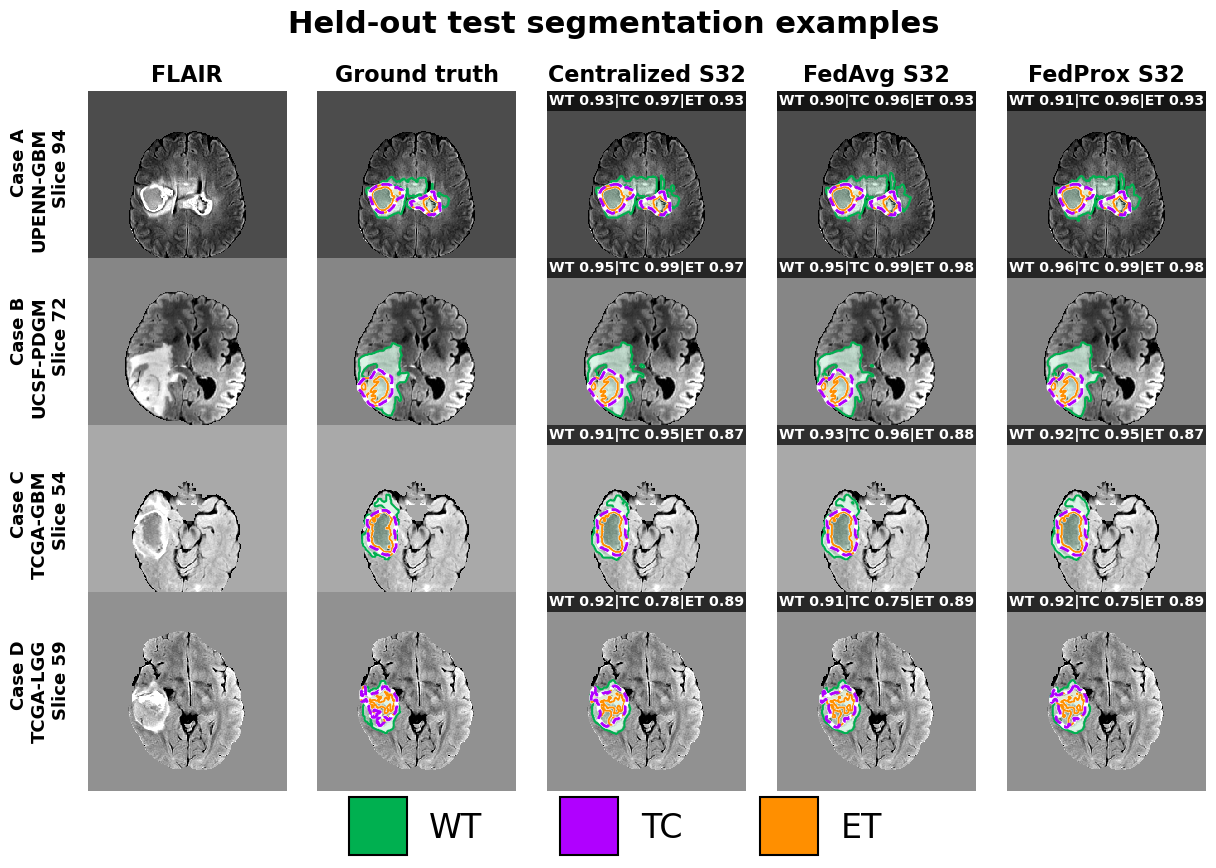

In [13]:
fig = create_paper_qualitative_figure()
save_paper_qualitative_figure(fig, paper_metadata_df)
plt.show()

## Full-test segmentation figures

In [14]:

EXPECTED_TEST_N = 211


def build_full_test_segmentation_tables():
    test_meta = test_df[["patient_id", "client_domain", "split"]].copy()
    test_meta["patient_id"] = test_meta["patient_id"].astype(str)

    if test_meta["patient_id"].duplicated().any():
        dup = test_meta.loc[test_meta["patient_id"].duplicated(), "patient_id"].tolist()
        raise ValueError(f"Duplicate patient IDs in test manifest: {dup[:10]}")

    expected_ids = set(test_meta["patient_id"])
    if len(expected_ids) != EXPECTED_TEST_N:
        raise ValueError(
            f"Paper figures require the full TEST split of {EXPECTED_TEST_N} patients; "
            f"manifest currently contains {len(expected_ids)}."
        )

    overall_rows = []
    domain_rows = []
    validated_frames = {}

    for model_key in MODEL_ORDER:
        df = metrics_by_model[model_key].copy()
        df["patient_id"] = df["patient_id"].astype(str)

        if df["patient_id"].duplicated().any():
            raise ValueError(f"{model_key}: duplicate patient IDs in full-volume metrics.")

        model_ids = set(df["patient_id"])
        missing = sorted(expected_ids - model_ids)
        extra = sorted(model_ids - expected_ids)

        if missing or extra or len(df) != EXPECTED_TEST_N:
            raise ValueError(
                f"{model_key}: metrics are not the complete {EXPECTED_TEST_N}-case TEST split. "
                f"n={len(df)}, missing={missing[:5]}, extra={extra[:5]}"
            )

        # Use domain labels from the held-out manifest.
        df = (
            df.drop(columns=["client_domain"], errors="ignore")
            .merge(test_meta[["patient_id", "client_domain"]], on="patient_id", how="left", validate="one_to_one")
        )

        if df["client_domain"].isna().any():
            raise ValueError(f"{model_key}: missing client_domain after manifest alignment.")

        df["dice_mean"] = df[["dice_WT", "dice_TC", "dice_ET"]].mean(axis=1)
        validated_frames[model_key] = df

        overall_rows.append({
            "model_key": model_key,
            "model_name": EXPERIMENTS[model_key]["display_name"],
            "n_cases": len(df),
            "WT Dice": float(df["dice_WT"].mean()),
            "TC Dice": float(df["dice_TC"].mean()),
            "ET Dice": float(df["dice_ET"].mean()),
            "Mean Dice": float(df["dice_mean"].mean()),
        })

        for domain, g in df.groupby("client_domain", sort=False):
            domain_rows.append({
                "model_key": model_key,
                "model_name": EXPERIMENTS[model_key]["display_name"],
                "client_domain": str(domain),
                "n_cases": int(len(g)),
                "ET Dice": float(g["dice_ET"].mean()),
                "WT Dice": float(g["dice_WT"].mean()),
                "TC Dice": float(g["dice_TC"].mean()),
                "Mean Dice": float(g["dice_mean"].mean()),
            })

    return (
        pd.DataFrame(overall_rows),
        pd.DataFrame(domain_rows),
        validated_frames,
    )


overall_test_dice_df, domain_test_dice_df, full_test_metrics_by_model = build_full_test_segmentation_tables()

print("Full-test segmentation patient count:", EXPECTED_TEST_N)
display(overall_test_dice_df.round(4))
display(domain_test_dice_df.round(4))

Full-test segmentation patient count: 211


,model_key,model_name,n_cases,WT Dice,TC Dice,ET Dice,Mean Dice
0,centralized_s32,Centralized S32,211,0.9223,0.9202,0.8740,0.9055
1,fedavg_s32,FedAvg S32,211,0.9127,0.9051,0.8719,0.8966
2,fedprox_s32,FedProx S32,211,0.9091,0.9020,0.8628,0.8913


,model_key,model_name,client_domain,n_cases,ET Dice,WT Dice,TC Dice,Mean Dice
0,centralized_s32,Centralized S32,UCSF-PDGM,76,0.8967,0.9199,0.9265,0.9144
1,centralized_s32,Centralized S32,TCGA-GBM,20,0.8444,0.9189,0.8880,0.8838
2,centralized_s32,Centralized S32,UPENN-GBM,102,0.9014,0.9259,0.9435,0.9236
3,centralized_s32,Centralized S32,TCGA-LGG,13,0.5719,0.9132,0.7511,0.7454
4,fedavg_s32,FedAvg S32,UCSF-PDGM,76,0.9005,0.9118,0.9292,0.9138
5,fedavg_s32,FedAvg S32,TCGA-GBM,20,0.8508,0.9024,0.9067,0.8866
6,fedavg_s32,FedAvg S32,UPENN-GBM,102,0.8969,0.9154,0.9397,0.9174
7,fedavg_s32,FedAvg S32,TCGA-LGG,13,0.5412,0.9131,0.4894,0.6479
8,fedprox_s32,FedProx S32,UCSF-PDGM,76,0.8926,0.9079,0.9213,0.9073
9,fedprox_s32,FedProx S32,TCGA-GBM,20,0.8333,0.8926,0.8850,0.8703


### Fig. 2 — Held-out test Dice

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_02_heldout_test_dice


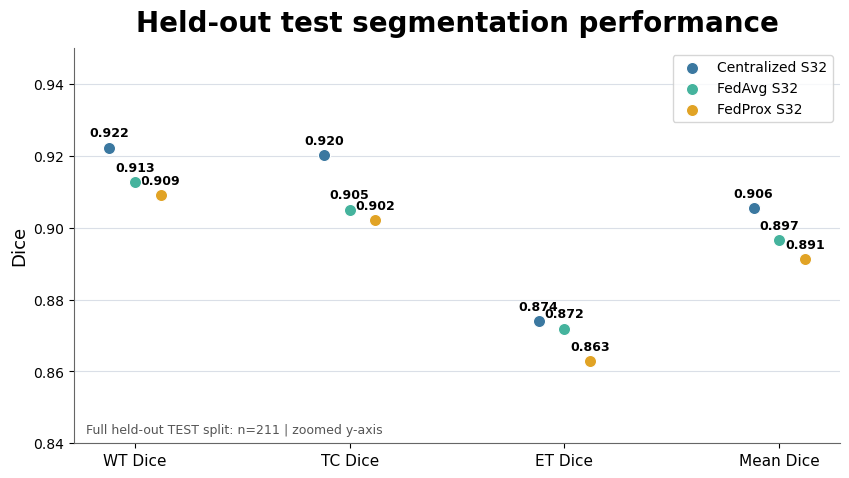

In [15]:

def plot_heldout_test_dice(save=True):
    metric_order = ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]
    x = np.arange(len(metric_order), dtype=float)
    offsets = {
        "centralized_s32": -0.12,
        "fedavg_s32": 0.0,
        "fedprox_s32": 0.12,
    }

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    style_paper_axes(ax, y_grid=True)

    for model_key in MODEL_ORDER:
        row = overall_test_dice_df.loc[
            overall_test_dice_df["model_key"] == model_key
        ].iloc[0]
        values = np.array([float(row[m]) for m in metric_order])
        xpos = x + offsets[model_key]

        ax.scatter(
            xpos,
            values,
            s=78,
            color=PAPER_MODEL_COLORS[model_key],
            edgecolor="white",
            linewidth=0.9,
            label=EXPERIMENTS[model_key]["display_name"],
            zorder=4,
        )

        for xi, value in zip(xpos, values):
            ax.text(
                xi,
                value + 0.0022,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

    ax.set_title("Held-out test segmentation performance", fontsize=20, fontweight="bold", pad=12)
    ax.set_ylabel("Dice", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_order, fontsize=11)
    ax.set_ylim(0.84, 0.95)
    ax.legend(loc="upper right", frameon=True, fontsize=10)
    ax.text(
        0.015,
        0.025,
        f"Full held-out TEST split: n={EXPECTED_TEST_N} | zoomed y-axis",
        transform=ax.transAxes,
        fontsize=9,
        color="#555555",
    )
    fig.subplots_adjust(top=0.90, left=0.11, right=0.98, bottom=0.14)

    if save:
        save_current_figure(fig, FIG_DIR / "figure_02_heldout_test_dice")
    return fig


fig_02 = plot_heldout_test_dice()
plt.show()

### Fig. 4 — Domain-stratified ET Dice

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_04_domain_stratified_et_dice


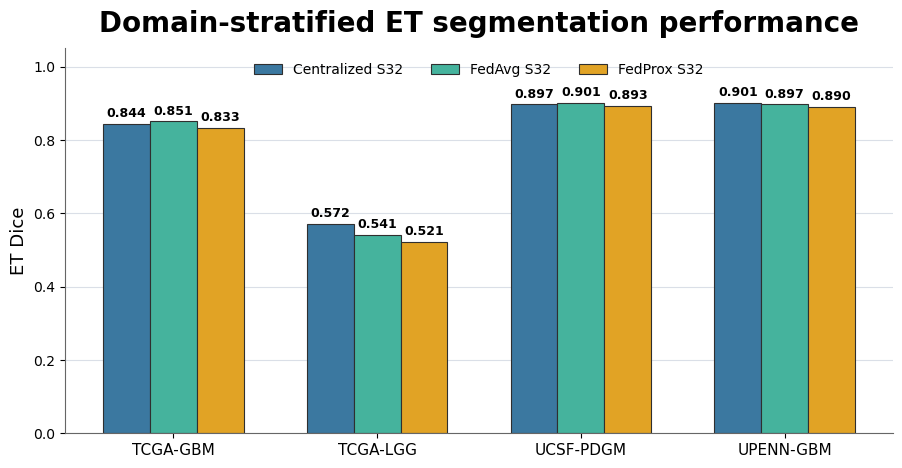

In [16]:

def plot_domain_stratified_et_dice(save=True):
    domain_order = ["TCGA-GBM", "TCGA-LGG", "UCSF-PDGM", "UPENN-GBM"]
    x = np.arange(len(domain_order), dtype=float)
    width = 0.23
    offsets = {
        "centralized_s32": -width,
        "fedavg_s32": 0.0,
        "fedprox_s32": width,
    }

    fig, ax = plt.subplots(figsize=(9.4, 5.5))
    style_paper_axes(ax, y_grid=True)

    for model_key in MODEL_ORDER:
        sub = domain_test_dice_df[
            domain_test_dice_df["model_key"] == model_key
        ].copy()
        sub["client_domain"] = pd.Categorical(
            sub["client_domain"], categories=domain_order, ordered=True
        )
        sub = sub.sort_values("client_domain")

        if sub["client_domain"].isna().any() or len(sub) != len(domain_order):
            raise ValueError(f"{model_key}: incomplete domain-stratified TEST metrics.")

        values = sub["ET Dice"].to_numpy(dtype=float)
        bars = ax.bar(
            x + offsets[model_key],
            values,
            width=width,
            label=EXPERIMENTS[model_key]["display_name"],
            color=PAPER_MODEL_COLORS[model_key],
            edgecolor=CFG["paper_bar_edgecolor"],
            linewidth=0.8,
        )
        add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=9, y_pad_frac=0.012)

    ax.set_title("Domain-stratified ET segmentation performance", fontsize=20, fontweight="bold", pad=12)
    ax.set_ylabel("ET Dice", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(domain_order, fontsize=11)
    ax.set_ylim(0.0, 1.05)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.995), ncol=3, frameon=False, fontsize=10)
    fig.subplots_adjust(top=0.84, left=0.10, right=0.98, bottom=0.14)

    if save:
        save_current_figure(fig, FIG_DIR / "figure_04_domain_stratified_et_dice")
    return fig


fig_04 = plot_domain_stratified_et_dice()
plt.show()

## Full-test retrieval figures

In [17]:

RETRIEVAL_ARTIFACTS = {
    "overall": "docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/11_pred_roi_overall_retrieval_metrics.csv",
    "center": "docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/13_pred_roi_center_diagnostics_overall.csv",
    "pred_vs_gt": "docs/08c_predicted_mask_roi_embedding_retrieval_test/tables/15_pred_roi_vs_gt_roi_overall_comparison.csv",
    "domain_matched": "docs/08d_predicted_roi_random_and_domain_matched_baselines_test/tables/10_domain_distribution_matched_control_embedding_k5.csv",
}

RETRIEVAL_KEY_MAP = {
    "centralized_s32_cew": "centralized_s32",
    "fedavg_s32_cew": "fedavg_s32",
    "fedprox_s32_cew": "fedprox_s32",
    "centralized_s32": "centralized_s32",
    "fedavg_s32": "fedavg_s32",
    "fedprox_s32": "fedprox_s32",
}


def load_optional_project_csv(path_like):
    path = resolve_existing_path(path_like, required=False, label=path_like)
    if path is None:
        return None, None
    return pd.read_csv(path), path


retrieval_loaded = {}
retrieval_paths = {}
for key, rel_path in RETRIEVAL_ARTIFACTS.items():
    df, path = load_optional_project_csv(rel_path)
    retrieval_loaded[key] = df
    retrieval_paths[key] = path

artifact_status_df = pd.DataFrame([
    {
        "artifact": key,
        "path": str(retrieval_paths[key]) if retrieval_paths[key] is not None else None,
        "loaded": retrieval_loaded[key] is not None,
    }
    for key in RETRIEVAL_ARTIFACTS
])
display(artifact_status_df)


def normalize_retrieval_key(series):
    out = series.astype(str).map(RETRIEVAL_KEY_MAP)
    if out.isna().any():
        bad = sorted(series[out.isna()].astype(str).unique())
        raise ValueError(f"Unknown retrieval experiment keys: {bad}")
    return out


# Fig. 5 and Fig. 9 use full-test 08c aggregate metrics.
if retrieval_loaded["overall"] is not None:
    retrieval_primary_df = retrieval_loaded["overall"].copy()
    retrieval_primary_df = retrieval_primary_df[
        (retrieval_primary_df["retrieval_space"].astype(str) == "embedding")
        & (retrieval_primary_df["k"].astype(int) == 5)
    ].copy()
    retrieval_primary_df["model_key"] = normalize_retrieval_key(retrieval_primary_df["experiment_key"])

    if set(retrieval_primary_df["model_key"]) != set(MODEL_ORDER):
        raise ValueError("08c overall metrics do not contain all three paper models at embedding @k=5.")
    if "n_queries" in retrieval_primary_df.columns and not (retrieval_primary_df["n_queries"].astype(int) == EXPECTED_TEST_N).all():
        raise ValueError("08c retrieval metrics are not based on the full 211-case TEST split.")
else:
    # If 08c tables are unavailable, use the published full-test aggregate values.
    retrieval_primary_df = pd.DataFrame([
        {"model_key": "centralized_s32", "n_queries": 211, "mean_abs_log1p_WT_diff": 0.5716, "mean_abs_log1p_TC_diff": 0.6330, "mean_abs_log1p_ET_diff": 0.7549, "mean_tumor_feature_z_distance": 1.2000, "same_domain_rate": 0.6711, "same_domain_enrichment": 2.43},
        {"model_key": "fedavg_s32", "n_queries": 211, "mean_abs_log1p_WT_diff": 0.4693, "mean_abs_log1p_TC_diff": 0.5870, "mean_abs_log1p_ET_diff": 0.6925, "mean_tumor_feature_z_distance": 1.1561, "same_domain_rate": 0.5678, "same_domain_enrichment": 1.77},
        {"model_key": "fedprox_s32", "n_queries": 211, "mean_abs_log1p_WT_diff": 0.4996, "mean_abs_log1p_TC_diff": 0.5998, "mean_abs_log1p_ET_diff": 0.7608, "mean_tumor_feature_z_distance": 1.1799, "same_domain_rate": 0.5611, "same_domain_enrichment": 1.74},
    ])

retrieval_primary_df["model_name"] = retrieval_primary_df["model_key"].map(
    {k: EXPERIMENTS[k]["display_name"] for k in MODEL_ORDER}
)


# Fig. 6 uses full-test predicted-WT center diagnostics.
if retrieval_loaded["center"] is not None:
    center_full_df = retrieval_loaded["center"].copy()
    center_full_df["model_key"] = normalize_retrieval_key(center_full_df["experiment_key"])
    if "n_cases" in center_full_df.columns and not (center_full_df["n_cases"].astype(int) == EXPECTED_TEST_N).all():
        raise ValueError("08c center diagnostics are not based on the full 211-case TEST split.")
else:
    center_full_df = pd.DataFrame([
        {"model_key": "centralized_s32", "n_cases": 211, "n_no_pred_wt": 0, "mean_pred_to_gt_wt_center_distance": 1.937, "median_pred_to_gt_wt_center_distance": 1.414},
        {"model_key": "fedavg_s32", "n_cases": 211, "n_no_pred_wt": 0, "mean_pred_to_gt_wt_center_distance": 2.468, "median_pred_to_gt_wt_center_distance": 1.414},
        {"model_key": "fedprox_s32", "n_cases": 211, "n_no_pred_wt": 0, "mean_pred_to_gt_wt_center_distance": 2.530, "median_pred_to_gt_wt_center_distance": 1.414},
    ])
center_full_df["model_name"] = center_full_df["model_key"].map(
    {k: EXPERIMENTS[k]["display_name"] for k in MODEL_ORDER}
)


# Fig. 7 uses full-test predicted-ROI minus GT-centered ROI deltas.
DELTA_METRICS = {
    "WT diff": "mean_abs_log1p_WT_diff_delta_pred_minus_gt",
    "TC diff": "mean_abs_log1p_TC_diff_delta_pred_minus_gt",
    "ET diff": "mean_abs_log1p_ET_diff_delta_pred_minus_gt",
    "z-distance": "mean_tumor_feature_z_distance_delta_pred_minus_gt",
}

if retrieval_loaded["pred_vs_gt"] is not None:
    pred_vs_gt_full_df = retrieval_loaded["pred_vs_gt"].copy()
    pred_vs_gt_full_df = pred_vs_gt_full_df[
        (pred_vs_gt_full_df["retrieval_space"].astype(str) == "embedding")
        & (pred_vs_gt_full_df["k"].astype(int) == 5)
    ].copy()
    pred_vs_gt_full_df["model_key"] = normalize_retrieval_key(pred_vs_gt_full_df["experiment_key"])
else:
    pred_vs_gt_full_df = pd.DataFrame([
        {"model_key": "centralized_s32", DELTA_METRICS["WT diff"]: 0.003, DELTA_METRICS["TC diff"]: 0.002, DELTA_METRICS["ET diff"]: 0.004, DELTA_METRICS["z-distance"]: 0.003},
        {"model_key": "fedavg_s32", DELTA_METRICS["WT diff"]: 0.016, DELTA_METRICS["TC diff"]: 0.010, DELTA_METRICS["ET diff"]: 0.006, DELTA_METRICS["z-distance"]: -0.0004},
        {"model_key": "fedprox_s32", DELTA_METRICS["WT diff"]: -0.010, DELTA_METRICS["TC diff"]: 0.001, DELTA_METRICS["ET diff"]: 0.007, DELTA_METRICS["z-distance"]: -0.005},
    ])


# Fig. 8 uses the full-test domain-distribution-matched random control.
if retrieval_loaded["domain_matched"] is not None:
    random_control_full_df = retrieval_loaded["domain_matched"].copy()
    random_control_full_df["model_key"] = normalize_retrieval_key(random_control_full_df["experiment_key"])
else:
    fallback_rows = []
    fallback_values = {
        "centralized_s32": [("mean_abs_log1p_WT_diff", 0.5716, 0.8543), ("mean_abs_log1p_TC_diff", 0.6330, 1.2655), ("mean_abs_log1p_ET_diff", 0.7549, 1.3253), ("mean_tumor_feature_z_distance", 1.2000, 1.3740)],
        "fedavg_s32": [("mean_abs_log1p_WT_diff", 0.4693, 0.8517), ("mean_abs_log1p_TC_diff", 0.5870, 1.2649), ("mean_abs_log1p_ET_diff", 0.6925, 1.3238), ("mean_tumor_feature_z_distance", 1.1561, 1.3750)],
        "fedprox_s32": [("mean_abs_log1p_WT_diff", 0.4996, 0.8529), ("mean_abs_log1p_TC_diff", 0.5998, 1.2615), ("mean_abs_log1p_ET_diff", 0.7608, 1.3372), ("mean_tumor_feature_z_distance", 1.1799, 1.3778)],
    }
    for model_key, rows in fallback_values.items():
        for metric, observed, baseline in rows:
            fallback_rows.append({
                "model_key": model_key,
                "metric": metric,
                "observed_value": observed,
                "baseline_mean": baseline,
                "baseline_ci95_low": np.nan,
                "baseline_ci95_high": np.nan,
            })
    random_control_full_df = pd.DataFrame(fallback_rows)

print("Retrieval figures use full-test aggregate data, not the four qualitative cases.")
display(retrieval_primary_df.round(4))
display(center_full_df.round(4))

,artifact,path,loaded
0,overall,/home/mandrakedrink/projects/research_ts_bs/do...,True
1,center,/home/mandrakedrink/projects/research_ts_bs/do...,True
2,pred_vs_gt,/home/mandrakedrink/projects/research_ts_bs/do...,True
3,domain_matched,/home/mandrakedrink/projects/research_ts_bs/do...,True


Retrieval figures use full-test aggregate data, not the four qualitative cases.


,experiment_key,retrieval_space,k,n_queries,same_domain_rate,cross_domain_rate,expected_same_domain_rate,same_domain_enrichment,same_ET_presence_rate,mean_abs_log1p_WT_diff,mean_abs_log1p_TC_diff,mean_abs_log1p_ET_diff,mean_tumor_feature_z_distance,mean_WT_centroid_distance,mean_TC_centroid_distance,mean_ET_centroid_distance,model_key,model_name
2,centralized_s32_cew,embedding,5,211,0.6711,0.3289,0.3732,2.4306,0.9848,0.5715,0.6330,0.7549,1.2000,54.0610,57.8930,58.1305,centralized_s32,Centralized S32
14,fedavg_s32_cew,embedding,5,211,0.5678,0.4322,0.3732,1.7661,0.9848,0.4693,0.5870,0.6925,1.1561,53.5754,56.8879,56.8354,fedavg_s32,FedAvg S32
26,fedprox_s32_cew,embedding,5,211,0.5611,0.4389,0.3732,1.7434,0.9810,0.4996,0.5998,0.7608,1.1799,54.3798,57.7992,57.9768,fedprox_s32,FedProx S32


,experiment_key,n_cases,n_no_pred_wt,no_pred_wt_rate,mean_pred_to_gt_wt_center_distance,median_pred_to_gt_wt_center_distance,pred_WT_median,gt_WT_median,pred_ET_median,gt_ET_median,model_key,model_name
0,centralized_s32_cew,211,0,0.0,1.9365,1.4142,93549.0,87527.0,16678.0,15058.0,centralized_s32,Centralized S32
1,fedavg_s32_cew,211,0,0.0,2.4682,1.4142,92810.0,87527.0,16558.0,15058.0,fedavg_s32,FedAvg S32
2,fedprox_s32_cew,211,0,0.0,2.5301,1.4142,93863.0,87527.0,17015.0,15058.0,fedprox_s32,FedProx S32


### Fig. 5  Predicted-mask ROI retrieval phenotype distances

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_05_pred_roi_embedding_distances_k5


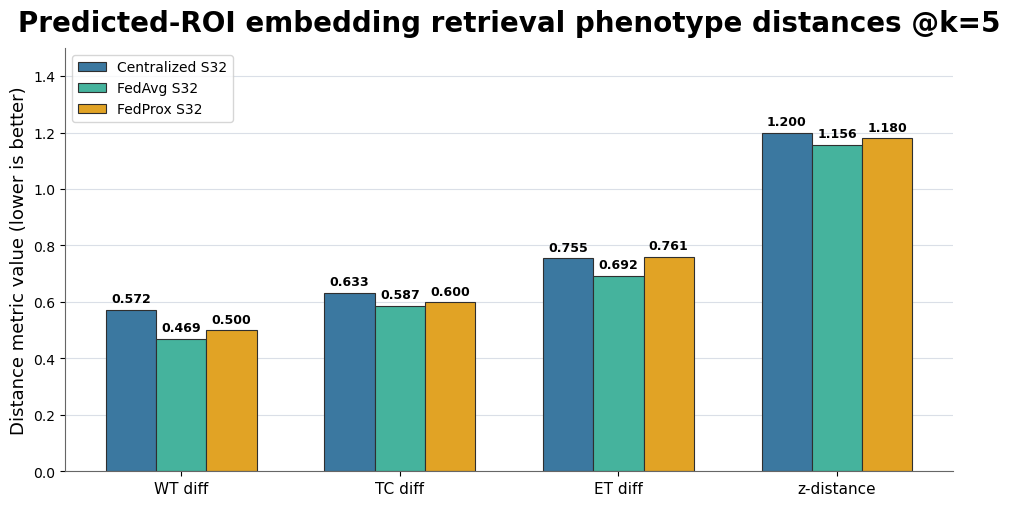

In [18]:

def plot_predicted_roi_embedding_distances(save=True):
    metric_map = [
        ("WT diff", "mean_abs_log1p_WT_diff"),
        ("TC diff", "mean_abs_log1p_TC_diff"),
        ("ET diff", "mean_abs_log1p_ET_diff"),
        ("z-distance", "mean_tumor_feature_z_distance"),
    ]
    x = np.arange(len(metric_map), dtype=float)
    width = 0.23

    fig, ax = plt.subplots(figsize=(10.2, 5.8))
    style_paper_axes(ax, y_grid=True)

    for idx, model_key in enumerate(MODEL_ORDER):
        row = retrieval_primary_df.loc[retrieval_primary_df["model_key"] == model_key].iloc[0]
        values = np.array([float(row[col]) for _, col in metric_map])
        bars = ax.bar(
            x + (idx - 1) * width,
            values,
            width=width,
            label=EXPERIMENTS[model_key]["display_name"],
            color=PAPER_MODEL_COLORS[model_key],
            edgecolor=CFG["paper_bar_edgecolor"],
            linewidth=0.8,
        )
        add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=9, y_pad_frac=0.012)

    ax.set_title("Predicted-ROI embedding retrieval phenotype distances @k=5", fontsize=20, fontweight="bold", pad=12)
    ax.set_ylabel("Distance metric value (lower is better)", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([label for label, _ in metric_map], fontsize=11)
    ax.legend(loc="upper left", frameon=True, fontsize=10)
    ax.set_ylim(0.0, 1.50)
    fig.subplots_adjust(top=0.88, left=0.11, right=0.98, bottom=0.15)

    if save:
        save_current_figure(fig, FIG_DIR / "figure_05_pred_roi_embedding_distances_k5")
    return fig


fig_05 = plot_predicted_roi_embedding_distances()
plt.show()

### Fig. 6  Predicted ROI center diagnostics

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_06_pred_roi_localization_accuracy


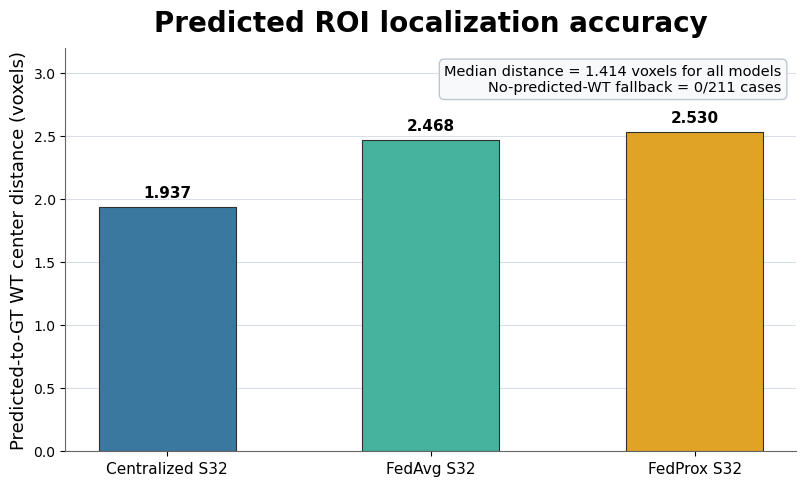

In [19]:

def plot_predicted_roi_localization_accuracy(save=True):
    plot_df = center_full_df.set_index("model_key").loc[MODEL_ORDER].reset_index()
    x = np.arange(len(MODEL_ORDER))
    values = plot_df["mean_pred_to_gt_wt_center_distance"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(8.6, 5.6))
    style_paper_axes(ax, y_grid=True)

    bars = ax.bar(
        x,
        values,
        color=[PAPER_MODEL_COLORS[m] for m in MODEL_ORDER],
        edgecolor=CFG["paper_bar_edgecolor"],
        linewidth=0.8,
        width=0.52,
    )
    add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=11, y_pad_frac=0.02)

    median_value = float(np.nanmedian(plot_df["median_pred_to_gt_wt_center_distance"].to_numpy(dtype=float)))
    n_fallback = int(plot_df.get("n_no_pred_wt", pd.Series([0] * len(plot_df))).sum())

    ax.set_title("Predicted ROI localization accuracy", fontsize=20, fontweight="bold", pad=12)
    ax.set_ylabel("Predicted-to-GT WT center distance (voxels)", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([EXPERIMENTS[m]["display_name"] for m in MODEL_ORDER], fontsize=11)
    ax.set_ylim(0.0, max(3.2, float(values.max()) * 1.24))
    ax.text(
        0.98,
        0.96,
        f"Median distance = {median_value:.3f} voxels for all models\n"
        f"No-predicted-WT fallback = {n_fallback}/{EXPECTED_TEST_N} cases",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#F7F9FB", edgecolor="#BFC7D1"),
    )
    fig.subplots_adjust(top=0.86, left=0.13, right=0.98, bottom=0.14)

    if save:
        save_current_figure(fig, FIG_DIR / "figure_06_pred_roi_localization_accuracy")
    return fig


fig_06 = plot_predicted_roi_localization_accuracy()
plt.show()

### Fig. 7  Predicted-ROI versus GT-centered ROI ablation

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_07_pred_roi_minus_gt_deltas_k5


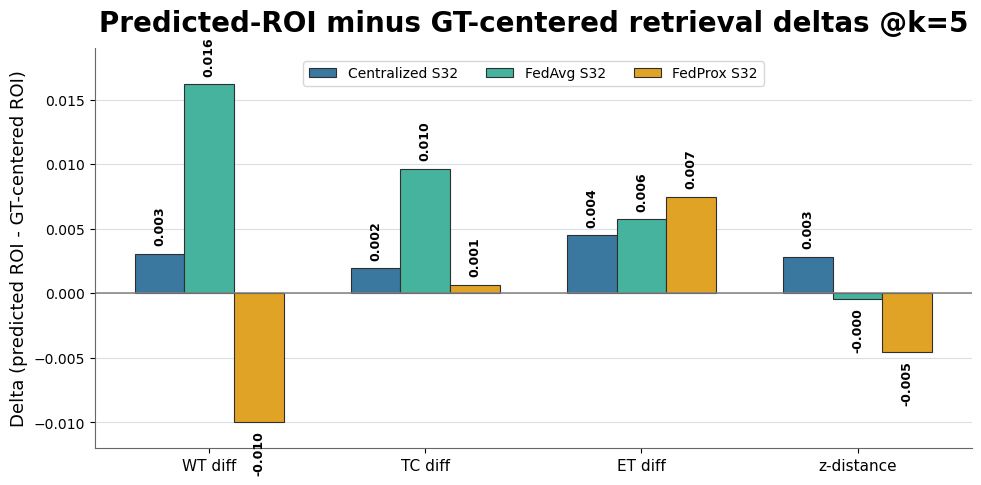

In [20]:

def plot_predicted_roi_minus_gt_deltas(save=True):
    metric_order = list(DELTA_METRICS.keys())
    x = np.arange(len(metric_order), dtype=float)
    width = 0.23

    fig, ax = plt.subplots(figsize=(10.2, 5.8))
    style_paper_axes(ax, y_grid=True)
    ax.axhline(0.0, color="#808080", linewidth=1.1)

    for idx, model_key in enumerate(MODEL_ORDER):
        row = pred_vs_gt_full_df.loc[pred_vs_gt_full_df["model_key"] == model_key].iloc[0]
        values = np.array([float(row[DELTA_METRICS[m]]) for m in metric_order])
        bars = ax.bar(
            x + (idx - 1) * width,
            values,
            width=width,
            label=EXPERIMENTS[model_key]["display_name"],
            color=PAPER_MODEL_COLORS[model_key],
            edgecolor=CFG["paper_bar_edgecolor"],
            linewidth=0.8,
        )
        for bar in bars:
            h = float(bar.get_height())
            pad = 0.00065 if h >= 0 else -0.00065
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                h + pad,
                f"{h:.3f}",
                ha="center",
                va="bottom" if h >= 0 else "top",
                fontsize=9,
                fontweight="bold",
                rotation=90,
            )

    ax.set_title("Predicted-ROI minus GT-centered retrieval deltas @k=5", fontsize=20, fontweight="bold", pad=12)
    ax.set_ylabel("Delta (predicted ROI - GT-centered ROI)", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_order, fontsize=11)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=3, frameon=True, fontsize=10)

    all_values = np.array([
        float(row[col])
        for _, row in pred_vs_gt_full_df.iterrows()
        for col in DELTA_METRICS.values()
    ])
    lower = min(-0.012, float(np.nanmin(all_values)) - 0.002)
    upper = max(0.019, float(np.nanmax(all_values)) + 0.002)
    ax.set_ylim(lower, upper)
    fig.subplots_adjust(top=0.84, left=0.12, right=0.98, bottom=0.15)

    if save:
        save_current_figure(fig, FIG_DIR / "figure_07_pred_roi_minus_gt_deltas_k5")
    return fig


fig_07 = plot_predicted_roi_minus_gt_deltas()
plt.show()

### Fig. 8  Observed retrieval versus domain-matched random

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_08_pred_roi_observed_vs_domain_matched_random_k5


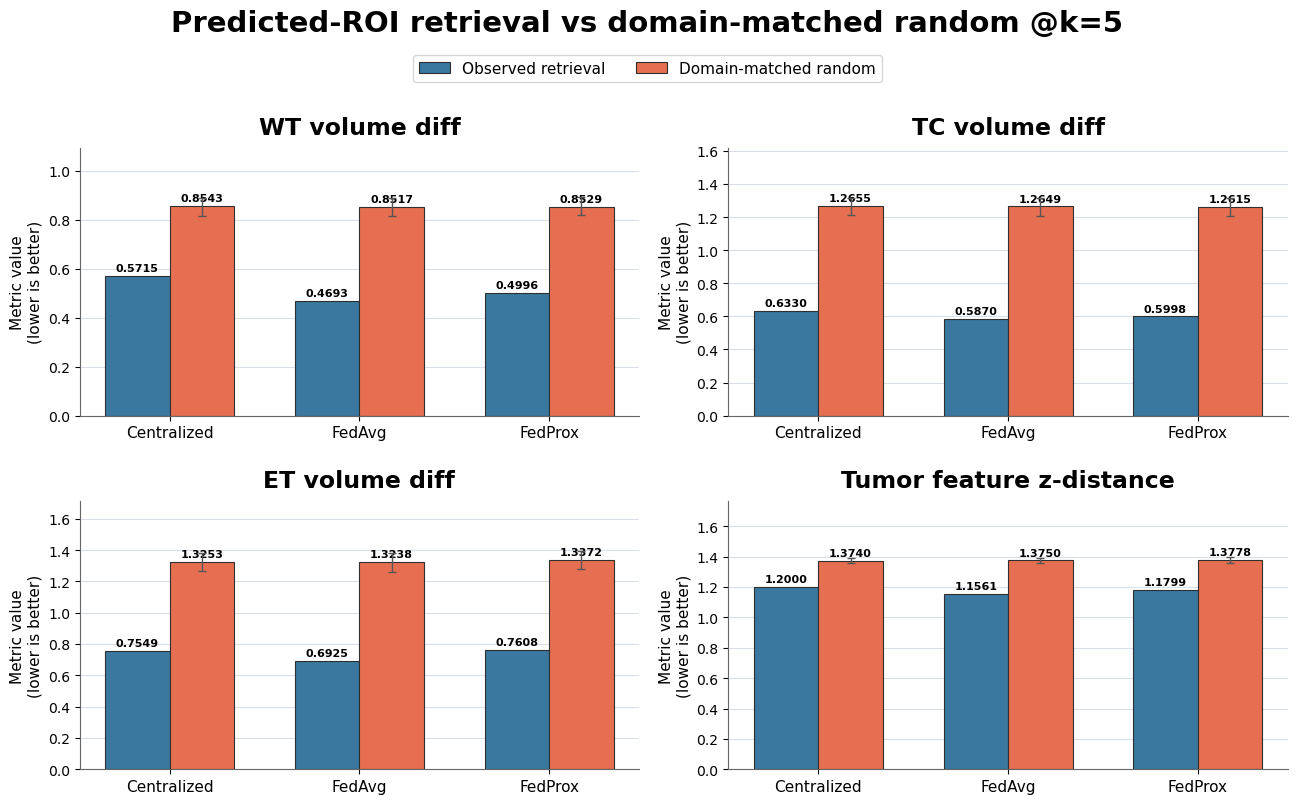

In [21]:

def plot_observed_vs_random_baseline(save=True):
    metric_specs = [
        ("mean_abs_log1p_WT_diff", "WT volume diff"),
        ("mean_abs_log1p_TC_diff", "TC volume diff"),
        ("mean_abs_log1p_ET_diff", "ET volume diff"),
        ("mean_tumor_feature_z_distance", "Tumor feature z-distance"),
    ]
    model_short = ["Centralized", "FedAvg", "FedProx"]
    x = np.arange(len(MODEL_ORDER), dtype=float)
    width = 0.34

    fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.4))
    axes = axes.ravel()

    for ax, (metric, title) in zip(axes, metric_specs):
        style_paper_axes(ax, y_grid=True)
        sub = random_control_full_df[random_control_full_df["metric"].astype(str) == metric].copy()
        sub = sub.set_index("model_key").reindex(MODEL_ORDER)

        if sub["observed_value"].isna().any() or sub["baseline_mean"].isna().any():
            raise ValueError(f"Incomplete full-test domain-matched control for {metric}.")

        obs_vals = sub["observed_value"].to_numpy(dtype=float)
        rnd_vals = sub["baseline_mean"].to_numpy(dtype=float)

        bars_obs = ax.bar(
            x - width / 2,
            obs_vals,
            width=width,
            color=PAPER_MODEL_COLORS["centralized_s32"],
            edgecolor=CFG["paper_bar_edgecolor"],
            linewidth=0.8,
            label="Observed retrieval",
        )
        bars_rnd = ax.bar(
            x + width / 2,
            rnd_vals,
            width=width,
            color=PAPER_RANDOM_BASELINE_COLOR,
            edgecolor=CFG["paper_bar_edgecolor"],
            linewidth=0.8,
            label="Domain-matched random",
        )

        if {"baseline_ci95_low", "baseline_ci95_high"}.issubset(sub.columns):
            low = sub["baseline_ci95_low"].to_numpy(dtype=float)
            high = sub["baseline_ci95_high"].to_numpy(dtype=float)
            if np.isfinite(low).any() and np.isfinite(high).any():
                yerr = np.vstack([
                    np.maximum(rnd_vals - low, 0.0),
                    np.maximum(high - rnd_vals, 0.0),
                ])
                ax.errorbar(
                    x + width / 2,
                    rnd_vals,
                    yerr=yerr,
                    fmt="none",
                    ecolor="#555555",
                    elinewidth=1.0,
                    capsize=3,
                    zorder=5,
                )

        add_bar_labels(ax, bars_obs, fmt="{:.4f}", fontsize=8, y_pad_frac=0.012)
        add_bar_labels(ax, bars_rnd, fmt="{:.4f}", fontsize=8, y_pad_frac=0.012)

        ax.set_title(title, fontsize=17, fontweight="bold", pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(model_short, fontsize=11)
        ax.set_ylabel("Metric value\n(lower is better)", fontsize=11)
        ymax = max(float(obs_vals.max()), float(rnd_vals.max()))
        ax.set_ylim(0.0, ymax * 1.28)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle("Predicted-ROI retrieval vs domain-matched random @k=5", fontsize=21, fontweight="bold", y=0.985)
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=2, frameon=True, fontsize=11)
    fig.subplots_adjust(top=0.82, left=0.07, right=0.985, bottom=0.08, hspace=0.32, wspace=0.16)

    if save:
        save_current_figure(fig, FIG_DIR / "figure_08_pred_roi_observed_vs_domain_matched_random_k5")
    return fig


fig_08 = plot_observed_vs_random_baseline()
plt.show()

### Fig. 9 Domain clustering diagnostic

saved: /home/mandrakedrink/projects/research_ts_bs/docs/09_qualitative_segmentation_examples_test/figures/figure_09_pred_roi_domain_clustering_k5


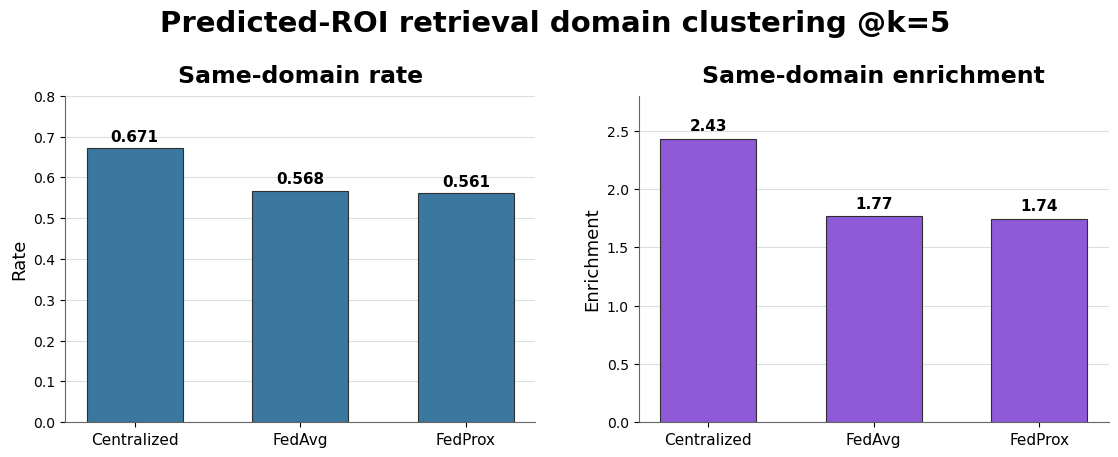

In [22]:

def plot_domain_clustering_diagnostic(save=True):
    plot_df = retrieval_primary_df.set_index("model_key").loc[MODEL_ORDER].reset_index()
    x = np.arange(len(MODEL_ORDER))
    model_short = ["Centralized", "FedAvg", "FedProx"]

    fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.8))

    ax = axes[0]
    style_paper_axes(ax, y_grid=True)
    bars = ax.bar(
        x,
        plot_df["same_domain_rate"].to_numpy(dtype=float),
        color=PAPER_MODEL_COLORS["centralized_s32"],
        edgecolor=CFG["paper_bar_edgecolor"],
        linewidth=0.8,
        width=0.58,
    )
    add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=11, y_pad_frac=0.015)
    ax.set_title("Same-domain rate", fontsize=17, fontweight="bold", pad=10)
    ax.set_ylabel("Rate", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(model_short, fontsize=11)
    ax.set_ylim(0.0, 0.80)

    ax = axes[1]
    style_paper_axes(ax, y_grid=True)
    bars = ax.bar(
        x,
        plot_df["same_domain_enrichment"].to_numpy(dtype=float),
        color=PAPER_ENRICHMENT_COLOR,
        edgecolor=CFG["paper_bar_edgecolor"],
        linewidth=0.8,
        width=0.58,
    )
    add_bar_labels(ax, bars, fmt="{:.2f}", fontsize=11, y_pad_frac=0.018)
    ax.set_title("Same-domain enrichment", fontsize=17, fontweight="bold", pad=10)
    ax.set_ylabel("Enrichment", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(model_short, fontsize=11)
    ax.set_ylim(0.0, max(2.8, float(plot_df["same_domain_enrichment"].max()) * 1.15))

    fig.suptitle("Predicted-ROI retrieval domain clustering @k=5", fontsize=21, fontweight="bold", y=0.98)
    fig.subplots_adjust(top=0.80, left=0.07, right=0.985, bottom=0.12, wspace=0.22)

    if save:
        save_current_figure(fig, FIG_DIR / "figure_09_pred_roi_domain_clustering_k5")
    return fig


fig_09 = plot_domain_clustering_diagnostic()
plt.show()